<a href="https://colab.research.google.com/github/PalakMallik/titanic-survival-prediction/blob/main/titanic-survival-predictor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Titanic Survival Prediction - Logistic Regression**

Load libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore", category = FutureWarning)

sns.set_style("whitegrid")

# 1. Load dataset

In [ ]:
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
df.shape

(891, 15)

In [ ]:
# | Feature         | Data Type     | Description                                                                                                        |
# | --------------- | ------------- | ------------------------------------------------------------------------------------------------------------------ |
# | **survived**    | Integer (0/1) | **Target variable.** Indicates whether the passenger survived. `0 = No`, `1 = Yes`.                                |
# | **pclass**      | Integer       | Passenger class. `1 = First`, `2 = Second`, `3 = Third`. Lower class numbers indicate higher socioeconomic status. |
# | **sex**         | Categorical   | Gender of the passenger (`male`, `female`).                                                                        |
# | **age**         | Float         | Age of the passenger in years. Some values are missing.                                                            |
# | **sibsp**       | Integer       | Number of siblings or spouses aboard the Titanic.                                                                  |
# | **parch**       | Integer       | Number of parents or children aboard the Titanic.                                                                  |
# | **fare**        | Float         | Fare paid by the passenger (in British Pounds).                                                                    |
# | **embarked**    | Categorical   | Port where the passenger boarded the ship. `C = Cherbourg`, `Q = Queenstown`, `S = Southampton`.                   |
# | **class**       | Categorical   | Passenger class as text (`First`, `Second`, `Third`). It conveys the same information as `pclass`.                 |
# | **who**         | Categorical   | Passenger category based on age and sex (`man`, `woman`, `child`).                                                 |
# | **adult_male**  | Boolean       | `True` if the passenger is an adult male, otherwise `False`.                                                       |
# | **deck**        | Categorical   | Cabin deck (`A`–`G`). Many values are missing because cabin information wasn't available for all passengers.       |
# | **embark_town** | Categorical   | Full name of the embarkation port (`Cherbourg`, `Queenstown`, `Southampton`). Same information as `embarked`.      |
# | **alive**       | Categorical   | Survival status as text (`yes`, `no`). Same information as `survived`.                                             |
# | **alone**       | Boolean       | `True` if the passenger traveled alone (`sibsp + parch = 0`), otherwise `False`.                                   |


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


# 2. Exploratory Data Analysis

Check which features actually drive survival

Text(0.5, 1.0, 'Survival rate by class')

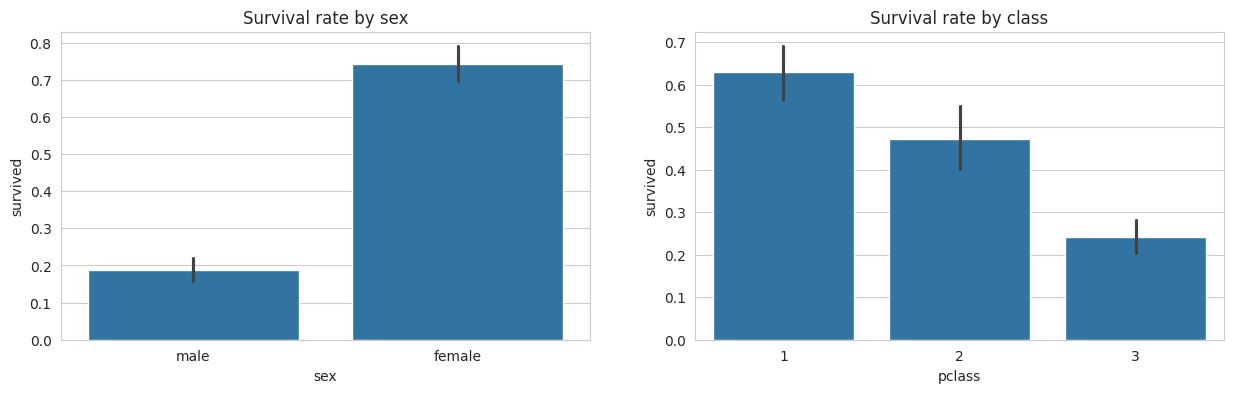

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4))

sns.barplot(data = df, x = 'sex', y = 'survived', ax = axes[0])
axes[0].set_title("Survival rate by sex")

sns.barplot(data = df, x = 'pclass', y = 'survived', ax = axes[1])
axes[1].set_title("Survival rate by class")

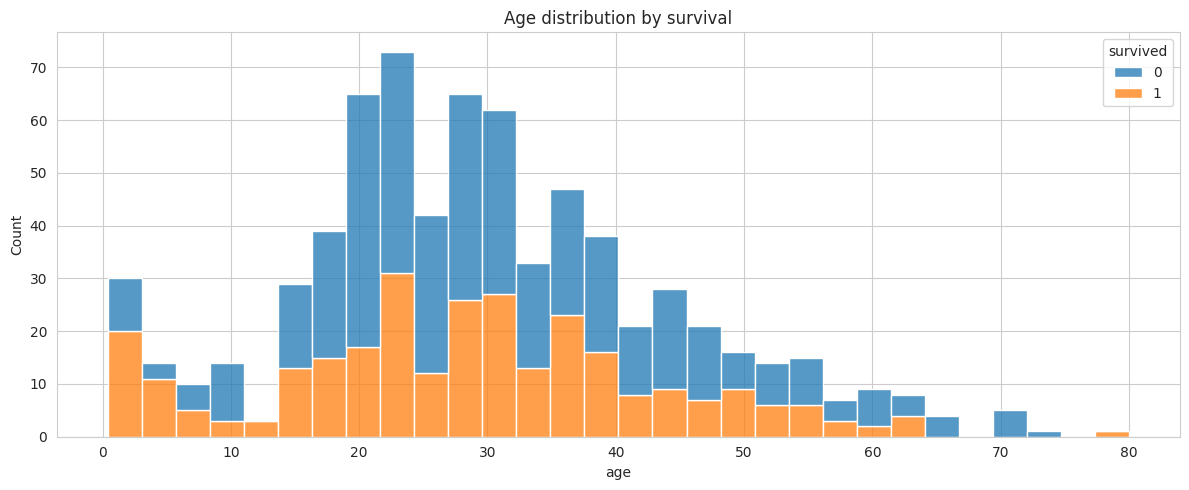

In [ ]:
plt.figure(figsize = (12, 5))
sns.histplot(data = df, x = 'age', hue = 'survived', multiple = "stack", bins=30)
plt.title("Age distribution by survival")

plt.tight_layout()
plt.show()

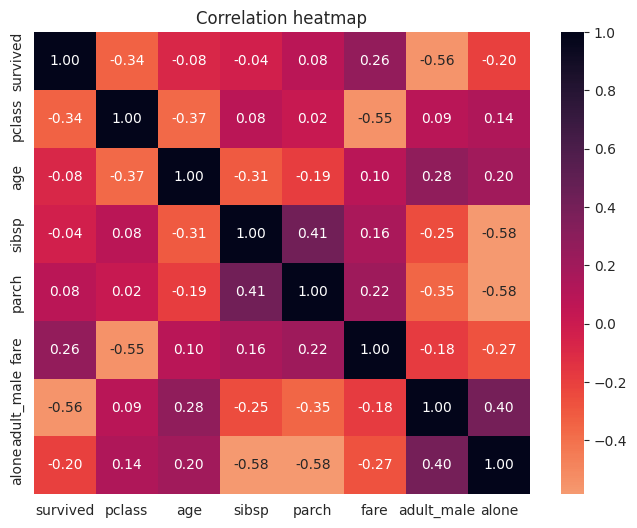

In [ ]:
plt.figure(figsize = (8, 6))
sns.heatmap(df.corr(numeric_only = True), annot=True, fmt=".2f", cmap = "rocket_r", center=0)
plt.title("Correlation heatmap")
plt.show()

Conclusion : Survival rate of females, upper class passengers and passengers of mid - age group (20 - 40) is comparatively high.

# 3. Handle null values and redundant columns

In [ ]:
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,2
class,0
who,0


In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [ ]:
# deck : 203 / 891 missing  --> drop
# embark_town : same as embarked --> drop
# alive : same as target - survived --> drop
# class : same as pclass --> drop
# who : derived from age + sex, mostly redundant with fields we're going to keep --> drop
# adult_male : derived from age + sex --> drop

In [ ]:
df.drop(["deck", "embark_town", "alive", "class", "who", "adult_male"], axis=1, inplace=True)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 9 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   survived  891 non-null    int64  
 1   pclass    891 non-null    int64  
 2   sex       891 non-null    object 
 3   age       714 non-null    float64
 4   sibsp     891 non-null    int64  
 5   parch     891 non-null    int64  
 6   fare      891 non-null    float64
 7   embarked  889 non-null    object 
 8   alone     891 non-null    bool   
dtypes: bool(1), float64(2), int64(4), object(2)
memory usage: 56.7+ KB


In [ ]:
# embarked has only 2 missing rows --> safe to drop
df.dropna(subset = ['embarked'], inplace = True)
df.isnull().sum()

,0
survived,0
pclass,0
sex,0
age,177
sibsp,0
parch,0
fare,0
embarked,0
alone,0


## Handle duplicate rows

In [ ]:
# df[df.duplicated(keep = False)]

In [ ]:
df.duplicated().sum()

np.int64(111)

In [ ]:
# df.drop_duplicates(inplace = True)
# df.duplicated().sum()

In [ ]:
# Since this dataset does not contain passenger ID or name
# column, two different people can share identical pclass,
# sex, age, fare, embarked values. They aren't duplicate records
# , they are distinct passengers with common profiles.
# Therefore, we will not remove them.

***"age" column's null cells are filled with mean later (after splitting training and testing data)***

In [ ]:
df.shape

(889, 9)

# 4. Feature engineering

In [ ]:
# sibsp = siblings + spouse
# parch = parents + children

df['family_size'] = df['sibsp'] + df['parch'] + 1
df[['sibsp', 'parch', 'family_size', 'alone']].head(10)


,sibsp,parch,family_size,alone
0,1,0,2,False
1,1,0,2,False
2,0,0,1,True
3,1,0,2,False
4,0,0,1,True
5,0,0,1,True
6,0,0,1,True
7,3,1,5,False
8,0,2,3,False
9,1,0,2,False


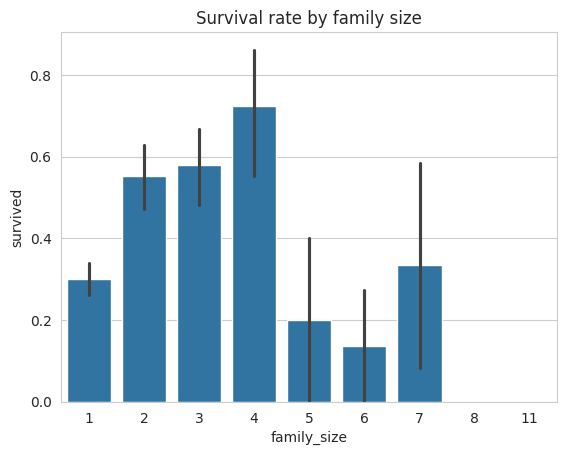

In [ ]:
# Let's check survival rate by family size

sns.barplot(data = df, x = 'family_size', y = 'survived')
plt.title("Survival rate by family size")
plt.show()

Conclusion : Passengers traveling in small families (2–4 members) had the highest chance of survival, while passengers traveling alone or in large families (>4) generally had lower survival rates.

# Encoding

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     889 non-null    int64  
 1   pclass       889 non-null    int64  
 2   sex          889 non-null    object 
 3   age          712 non-null    float64
 4   sibsp        889 non-null    int64  
 5   parch        889 non-null    int64  
 6   fare         889 non-null    float64
 7   embarked     889 non-null    object 
 8   alone        889 non-null    bool   
 9   family_size  889 non-null    int64  
dtypes: bool(1), float64(2), int64(5), object(2)
memory usage: 70.3+ KB


In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,alone,family_size
0,0,3,male,22.0,1,0,7.2500,S,False,2
1,1,1,female,38.0,1,0,71.2833,C,False,2
2,1,3,female,26.0,0,0,7.9250,S,True,1
3,1,1,female,35.0,1,0,53.1000,S,False,2
4,0,3,male,35.0,0,0,8.0500,S,True,1


In [ ]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

## Label encoding

In [ ]:
df['embarked'].value_counts()

,count
embarked,
S,644
C,168
Q,77


In [ ]:
# `C = Cherbourg`, `Q = Queenstown`, `S = Southampton`

In [ ]:
for col in ['sex', 'alone']:
  df[col] = le.fit_transform(df[col])

# One - hot - encoding

In [ ]:
df = pd.get_dummies(df, columns = ['embarked'], dtype = int)

In [ ]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,alone,family_size,embarked_C,embarked_Q,embarked_S
0,0,3,1,22.0,1,0,7.2500,0,2,0,0,1
1,1,1,0,38.0,1,0,71.2833,0,2,1,0,0
2,1,3,0,26.0,0,0,7.9250,1,1,0,0,1
3,1,1,0,35.0,1,0,53.1000,0,2,0,0,1
4,0,3,1,35.0,0,0,8.0500,1,1,0,0,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 889 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   survived     889 non-null    int64  
 1   pclass       889 non-null    int64  
 2   sex          889 non-null    int64  
 3   age          712 non-null    float64
 4   sibsp        889 non-null    int64  
 5   parch        889 non-null    int64  
 6   fare         889 non-null    float64
 7   alone        889 non-null    int64  
 8   family_size  889 non-null    int64  
 9   embarked_C   889 non-null    int64  
 10  embarked_Q   889 non-null    int64  
 11  embarked_S   889 non-null    int64  
dtypes: float64(2), int64(10)
memory usage: 90.3 KB


# 6. Separate input features from target variable

In [ ]:
X = df.drop(columns = ['survived'], axis = 1)
y = df['survived']

# 7. Split training and testing data

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42)

In [ ]:
print(X_train.shape,"\n",X_test.shape)

(711, 11) 
 (178, 11)


# 8. Handle missing values (fill with mean)

In [ ]:
from sklearn.impute import SimpleImputer
imputer = SimpleImputer(strategy = "mean")

# fill mean in place of missing values

X_train['age'] = imputer.fit_transform(X_train[['age']])
X_test['age'] = imputer.transform(X_test[['age']])

# 9. Feature scaling

In [ ]:
X.head()

,pclass,sex,age,sibsp,parch,fare,alone,family_size,embarked_C,embarked_Q,embarked_S
0,3,1,22.0,1,0,7.2500,0,2,0,0,1
1,1,0,38.0,1,0,71.2833,0,2,1,0,0
2,3,0,26.0,0,0,7.9250,1,1,0,0,1
3,1,0,35.0,1,0,53.1000,0,2,0,0,1
4,3,1,35.0,0,0,8.0500,1,1,0,0,1


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scale_cols = ["age", "fare"]

X_train[scale_cols] = scaler.fit_transform(X_train[scale_cols])  # Fit and transform training data
X_test[scale_cols] = scaler.transform(X_test[scale_cols])  # Only transform test data

X_train.head()

,pclass,sex,age,sibsp,parch,fare,alone,family_size,embarked_C,embarked_Q,embarked_S
708,1,0,-6.029057e-01,0,0,2.430597,1,1,0,0,1
240,3,0,2.709361e-16,1,0,-0.358135,0,2,1,0,0
382,3,1,1.597115e-01,0,0,-0.490949,1,1,0,0,1
792,3,0,2.709361e-16,8,2,0.762595,0,11,0,0,1
683,3,1,-1.212999e+00,5,2,0.301860,0,8,0,0,1


In [ ]:
print(X_train.shape)
print(len(X.columns))
print(X.columns)

(711, 11)
11
Index(['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'alone',
       'family_size', 'embarked_C', 'embarked_Q', 'embarked_S'],
      dtype='object')


# 11. Model

In [ ]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

In [ ]:
model.fit(X_train, y_train)

LogisticRegression()

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
print(X_train.shape)
print(X_test.shape)

(711, 11)
(178, 11)


In [ ]:
y_pred

array([0, 1, 1, 0, 1, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 1, 1, 0, 0, 0, 1, 0, 0,
       0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0,
       0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 0,
       0, 0, 1, 1, 0, 1, 1, 1, 1, 0, 1, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       0, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 1, 0,
       0, 1])

In [ ]:
y_test

,survived
281,0
435,1
39,1
418,0
585,1
...,...
433,0
807,0
25,1
85,1


# 12. Model Evaluation

In [ ]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [ ]:
print("Confusion matrix : \n", confusion_matrix(y_test, y_pred))

Confusion matrix : 
 [[89 20]
 [16 53]]


In [ ]:
print("Accuracy score : ", accuracy_score(y_test, y_pred))

Accuracy score :  0.797752808988764


In [ ]:
print("Classification report : \n\n", classification_report(y_test, y_pred))

Classification report : 

               precision    recall  f1-score   support

           0       0.85      0.82      0.83       109
           1       0.73      0.77      0.75        69

    accuracy                           0.80       178
   macro avg       0.79      0.79      0.79       178
weighted avg       0.80      0.80      0.80       178

